In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
!jupyter nbconvert "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.ipynb" --to python
!jupyter nbconvert "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.ipynb" --to python
!jupyter nbconvert "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/predict.ipynb" --to python

[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.ipynb to python
[NbConvertApp] Writing 5544 bytes to /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/dataset.py
[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.ipynb to python
[NbConvertApp] Writing 4472 bytes to /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/modules.py
[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/predict.ipynb to python
[NbConvertApp] Writing 4721 bytes to /content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/predict.py


In [47]:
import sys, os

py_file_location = "/content/drive/My Drive/Colab Notebooks/Pattern Recognition Project/multi file solution/"
sys.path.append(os.path.abspath(py_file_location))

import importlib, dataset, modules, predict
importlib.reload(dataset)
importlib.reload(modules)
importlib.reload(predict)

from dataset import *
from modules import *
from predict import evaluate_model, plot_confusion_matrix, display_sample_predictions

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dir = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/AD_NC/train"
test_dir = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/AD_NC/test"

train_ds, val_ds, test_ds = create_datasets(train_dir, test_dir)
train_loader, val_loader, test_loader = create_dataloaders(train_ds, val_ds, test_ds)

Using device: cuda


In [61]:
def run_epoch(model, loader, criterion=None, optimizer=None, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    loop = tqdm(loader, desc="Training" if train else "Validation", leave=True)
    for data, targets in loop:
        data, targets = data.to(device), targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)


        if train:
            # APPLY MIXUP/CUTMIX
            #data, targets_a, targets_b, lam = mixup_cutmix_data(data, targets, alpha=1.0, cutmix_prob=0.5)
            # APPLY MIXUP/CUTMIX

            optimizer.zero_grad()
            #outputs = model(data)

            # COMPUTE MIXED LOSS
            #loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
            # COMPUTE MIXED LOSS

            loss.backward()
            optimizer.step()
        '''
        else:
            outputs = model(data)
            loss = criterion(outputs, targets)
        '''

        total_loss += loss.item()
        _, preds = outputs.max(1)
        total += targets.size(0)
        correct += preds.eq(targets).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

        acc = 100 * correct / total
        loop.set_postfix(Loss=f"{loss.item():.4f}", Acc=f"{acc:.2f}%")

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    f1 = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, accuracy, f1

In [63]:
'''
model = ConvNeXt(in_chans=1, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2.5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

num_epochs = 2
train_losses, val_losses = [], []
train_accuracies, val_accuracies, val_f1s = [], [], []
best_val_acc = 0.0
'''

model = ConvNeXt(in_chans=1, num_classes=2).to(device)

label_smoothing = 0.1
class_weights = count_classes(train_ds)
learning_rate = 3e-4
weight_decay = 1e-4
num_epochs = 120
num_warmup_epochs = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies, val_f1s = [], [], []
best_val_acc = 0.0
patience = 100
epochs_without_improvement = 0
early_stop = False

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing, weight=torch.tensor(class_weights, dtype=torch.float32, device=device))

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=num_warmup_epochs)
scheduler2 = CosineAnnealingLR(optimizer, T_max=(num_epochs - num_warmup_epochs), eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[num_warmup_epochs])

save_dir = "/content/drive/MyDrive/Colab Notebooks/Pattern Recognition Project/multi file solution/"


Dataset class distribution:
  AD: 8320
  NC: 8880
  Total: 17200


In [50]:
def rand_bbox(size, lam):
    """Generate random bbox for CutMix"""
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

In [51]:
def mixup_cutmix_data(x, y, alpha=1.0, cutmix_prob=0.5):
    """Apply MixUp or CutMix augmentation on a batch"""
    r = np.random.rand(1)
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size(0)).to(x.device)
    y_a, y_b = y, y[rand_index]

    if r < cutmix_prob:
        # ----- CutMix -----
        bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
        x[:, :, bbx1:bbx2, bby1:bby2] = x[rand_index, :, bbx1:bbx2, bby1:bby2]
        lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size()[-1] * x.size()[-2]))
    else:
        # ----- MixUp -----
        x = lam * x + (1 - lam) * x[rand_index, :]

    return x, y_a, y_b, lam

In [ ]:
print("🚀 Starting ConvNeXt training...\n")

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")
    print("-" * 40)

    train_loss, train_acc, _ = run_epoch(model, train_loader, criterion=criterion, optimizer=optimizer, train=True)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion=criterion, optimizer=None, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    val_f1s.append(val_f1)

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val Acc:   {val_acc:.2f}% | F1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs(save_dir, exist_ok=True)
        torch.save(model.state_dict(), os.path.join(save_dir, "best_convnext_adni.pth"))
        print(f"✅ New best model saved (Val Acc = {best_val_acc:.2f}%)")
        epochs_without_improvement = 0  # reset counter
    else:
      epochs_without_improvement += 1
      print(f"⚠️ No improvement for {epochs_without_improvement} epoch(s).")

      if epochs_without_improvement >= patience:
          print(f"⏹️ Early stopping triggered after {epoch} epochs!")
          early_stop = True
          break

print("\n🎉 Training complete!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

🚀 Starting ConvNeXt training...


Epoch 1/120
----------------------------------------


Validation: 100%|██████████| 34/34 [00:07<00:00,  4.40it/s, Acc=58.15%, Loss=0.6846]


Train Loss: 0.7153 | Train Acc: 50.04%
Val   Loss: 0.6876 | Val Acc:   58.15% | F1: 0.5452
✅ New best model saved (Val Acc = 58.15%)

Epoch 2/120
----------------------------------------


Validation: 100%|██████████| 34/34 [00:07<00:00,  4.57it/s, Acc=63.01%, Loss=0.7360]


Train Loss: 0.6747 | Train Acc: 58.95%
Val   Loss: 0.6574 | Val Acc:   63.01% | F1: 0.6101
✅ New best model saved (Val Acc = 63.01%)

Epoch 3/120
----------------------------------------


...

Validation: 100%|██████████| 34/34 [00:07<00:00,  4.51it/s, Acc=87.27%, Loss=0.7189]


Train Loss: 0.3627 | Train Acc: 89.70%
Val   Loss: 0.4006 | Val Acc:   87.27% | F1: 0.8727
✅ New best model saved (Val Acc = 87.27%)

Epoch 60/120
----------------------------------------


Validation: 100%|██████████| 34/34 [00:07<00:00,  4.46it/s, Acc=86.32%, Loss=0.6603]


Train Loss: 0.3576 | Train Acc: 89.77%
Val   Loss: 0.4107 | Val Acc:   86.32% | F1: 0.8632
⚠️ No improvement for 1 epoch(s).

Epoch 61/120
----------------------------------------


Training:   7%|▋         | 10/135 [00:06<01:01,  2.02it/s, Acc=91.33%, Loss=0.3597]

In [56]:
def plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies, val_f1s):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, "r-", label="Train Loss")
    plt.plot(epochs, val_losses, "g-", label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, "r-", label="Train Accuracy")
    plt.plot(epochs, val_accuracies, "g-", label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, val_f1s, "-b", label="Validation F1 Score")
    plt.title("Validation F1 Score")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

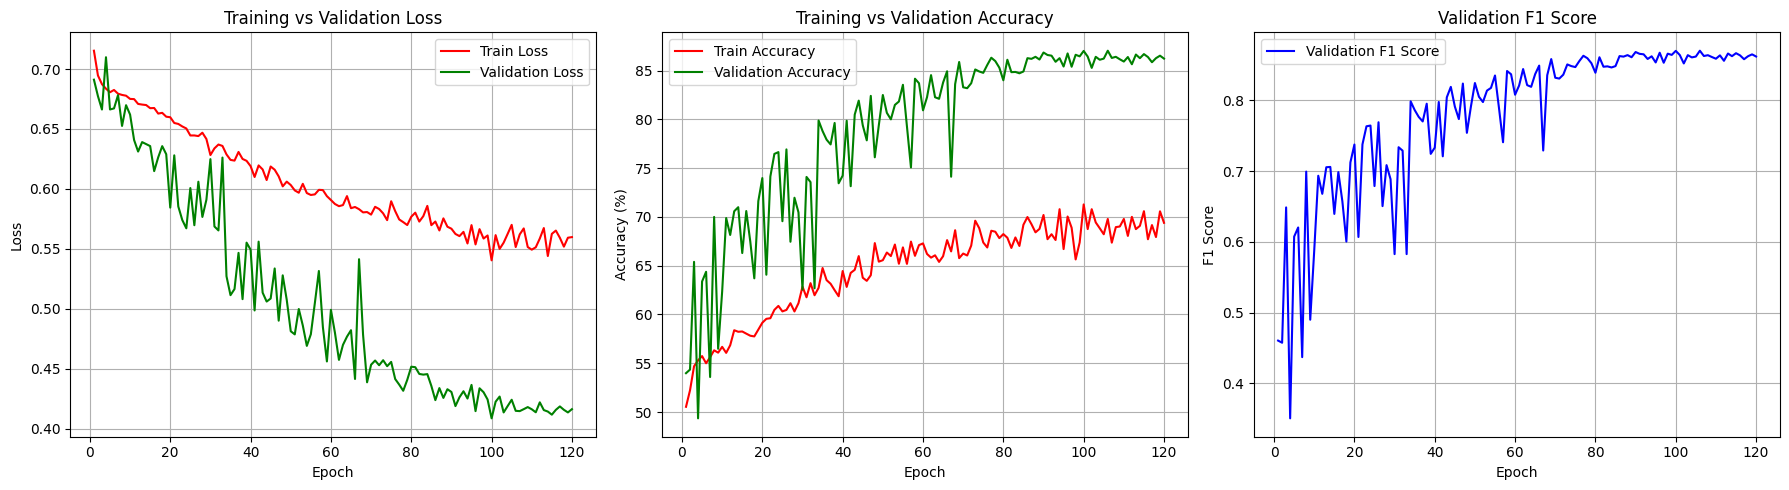

In [57]:
plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies, val_f1s)

In [58]:
model.load_state_dict(torch.load(os.path.join(save_dir, "best_convnext_adni.pth"), map_location=device))

accuracy, all_preds, all_targets, all_probs = evaluate_model(model, test_loader, device)




📊 Evaluating best model on test set...


Testing: 100%|██████████| 71/71 [00:13<00:00,  5.13it/s]


✅ Test Accuracy: 74.0556%

📋 Classification Report:
              precision    recall  f1-score   support

          AD     0.7806    0.6628    0.7169      4460
          NC     0.7115    0.8170    0.7606      4540

    accuracy                         0.7406      9000
   macro avg     0.7460    0.7399    0.7387      9000
weighted avg     0.7457    0.7406    0.7389      9000



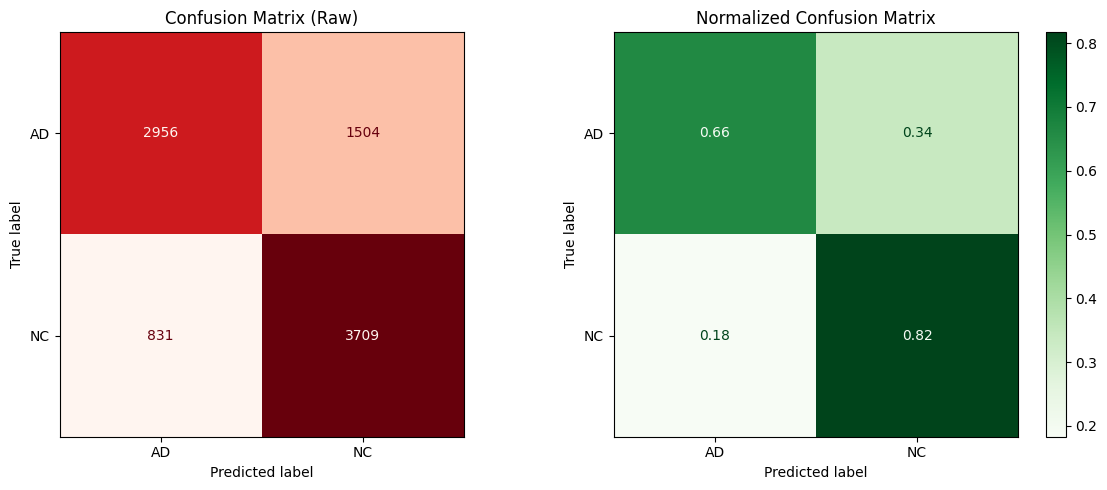

In [60]:
plot_confusion_matrix(all_targets, all_preds)